# Modelacao comentada a partir do EDA

Objetivo deste notebook:
- usar o ficheiro `ortho_eda_clean.csv`, que foi gerado no EDA;
- comparar tres modelos de classificacao para prever `mudanca_CPAK`;
- manter o codigo simples, legivel e todo comentado;
- escolher o melhor modelo com base nas metricas de validacao e depois testar no conjunto final.

Modelos incluidos:
1. Regressao Logistica
2. Arvore de Decisao
3. Random Forest

Estrategia geral:
- separar os dados em treino, validacao e teste;
- criar pipelines para evitar fugas de informacao;
- treinar um baseline de cada modelo;
- otimizar hiperparametros com `GridSearchCV`;
- comparar os resultados e guardar o melhor modelo.

In [8]:
# ============================================================
# 1) Importar bibliotecas e carregar o dataset final do EDA
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Ajuste estetico simples para os graficos.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Ler o ficheiro produzido no EDA.
df = pd.read_csv('ortho_eda_clean.csv')

# Verificacoes iniciais para entender o ponto de partida.
print('Dimensao do dataset:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nPrimeiras linhas:')
display(df.head())
print('\nValores em falta por coluna:')
print(df.isna().sum())

Dimensao do dataset: (262, 14)

Tipos de dados:
Idade             int64
Sexo              int64
Peso            float64
Altura_cm       float64
IMC             float64
Grupo_pre         int64
Fle_0           float64
EVA_0           float64
PM6_0           float64
WD_0              int64
WR_0            float64
WAtotal_0       float64
WT_0              int64
mudanca_CPAK      int64
dtype: object

Primeiras linhas:


,Idade,Sexo,Peso,Altura_cm,IMC,Grupo_pre,Fle_0,EVA_0,PM6_0,WD_0,WR_0,WAtotal_0,WT_0,mudanca_CPAK
0,67,0,80.0,158.0,32.046146,5,86.0,4.0,324.0,15,6.0,54.0,75,0
1,76,1,60.0,155.0,24.973985,5,90.0,4.0,357.0,14,7.0,39.0,60,0
2,72,1,93.0,182.0,28.076319,1,45.0,10.0,289.0,15,4.0,53.0,72,0
3,67,1,71.0,163.0,26.722873,6,127.0,2.0,390.0,1,1.0,16.0,18,0
4,66,0,49.0,160.0,19.140625,6,120.0,0.0,285.0,0,0.0,8.0,8,0



Valores em falta por coluna:
Idade           0
Sexo            0
Peso            0
Altura_cm       0
IMC             0
Grupo_pre       0
Fle_0           0
EVA_0           0
PM6_0           0
WD_0            0
WR_0            0
WAtotal_0       0
WT_0            0
mudanca_CPAK    0
dtype: int64


## 2. Preparacao dos dados

Neste trabalho o EDA ja removeu variaveis com data leakage e gravou um ficheiro limpo.

Mesmo assim, ainda vamos:
- separar a target das features;
- identificar colunas numericas e categoricas;
- criar preprocessadores dentro de `Pipeline` para que a imputacao, encoding e escalamento acontecam de forma correta;
- fazer a divisao em treino, validacao e teste com estratificacao, para manter a proporcao da classe alvo.

In [2]:
# ============================================================
# 2) Preparar target, features, divisao dos dados e funcoes uteis
# ============================================================

# Definir variavel-alvo e matriz de features.
X = df.drop(columns='mudanca_CPAK')
y = df['mudanca_CPAK']

# Neste dataset, estas duas variaveis sao tratadas como categoricas.
colunas_categoricas = ['Sexo', 'Grupo_pre']
colunas_numericas = [col for col in X.columns if col not in colunas_categoricas]

# Primeiro, separamos um conjunto final de teste.
# Este conjunto so sera usado no fim, depois da escolha do melhor modelo.
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Depois, dividimos o conjunto temporario em treino e validacao.
# O resultado final fica aproximadamente 60% treino, 20% validacao e 20% teste.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp,
)

# Mostrar a distribuicao da classe alvo em cada parte.
def mostrar_distribuicao(nome, serie):
    print(f'\nDistribuicao de {nome}:')
    print(serie.value_counts())
    print((serie.value_counts(normalize=True) * 100).round(2))

mostrar_distribuicao('y total', y)
mostrar_distribuicao('y treino', y_train)
mostrar_distribuicao('y validacao', y_val)
mostrar_distribuicao('y teste', y_test)

# Funcao para criar o preprocessador.
# Regressao Logistica precisa de escalamento nas variaveis numericas.
# Modelos de arvore nao precisam desse passo.
def criar_preprocessador(escalar_numericas=False):
    if escalar_numericas:
        bloco_numerico = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ])
    else:
        bloco_numerico = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ])

    bloco_categorico = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    preprocessador = ColumnTransformer([
        ('num', bloco_numerico, colunas_numericas),
        ('cat', bloco_categorico, colunas_categoricas),
    ])

    return preprocessador

# Funcao para calcular as metricas principais.
# A metrica principal deste notebook sera o F1-score,
# porque combina precision e recall numa unica medida.
def calcular_metricas(y_real, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_real, y_pred),
        'precision': precision_score(y_real, y_pred, zero_division=0),
        'recall': recall_score(y_real, y_pred, zero_division=0),
        'f1': f1_score(y_real, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_real, y_prob),
    }

# Funcao auxiliar para transformar dicionarios de metricas em DataFrame.
def metricas_para_df(nome_modelo, tipo_modelo, metricas):
    linha = {'modelo': nome_modelo, 'tipo': tipo_modelo}
    linha.update({chave: round(valor, 4) for chave, valor in metricas.items()})
    return linha


Distribuicao de y total:
mudanca_CPAK
0    236
1     26
Name: count, dtype: int64
mudanca_CPAK
0    90.08
1     9.92
Name: proportion, dtype: float64

Distribuicao de y treino:
mudanca_CPAK
0    140
1     16
Name: count, dtype: int64
mudanca_CPAK
0    89.74
1    10.26
Name: proportion, dtype: float64

Distribuicao de y validacao:
mudanca_CPAK
0    48
1     5
Name: count, dtype: int64
mudanca_CPAK
0    90.57
1     9.43
Name: proportion, dtype: float64

Distribuicao de y teste:
mudanca_CPAK
0    48
1     5
Name: count, dtype: int64
mudanca_CPAK
0    90.57
1     9.43
Name: proportion, dtype: float64


## 3. Regressao Logistica

Vamos começar por um baseline simples e depois fazer uma pequena otimizacao com validacao cruzada.

A Regressao Logistica costuma ser um bom ponto de partida porque:
- e facil de interpretar;
- funciona bem em problemas binarios;
- permite perceber se ja existe um sinal razoavel nos dados.

In [3]:
# ============================================================
# 3) Baseline e tuning da Regressao Logistica
# ============================================================

# Criar pipeline baseline.
pipeline_lr_base = Pipeline([
    ('preprocessamento', criar_preprocessador(escalar_numericas=True)),
    ('modelo', LogisticRegression(max_iter=2000, random_state=42)),
])

# Treinar baseline apenas com o conjunto de treino.
pipeline_lr_base.fit(X_train, y_train)

# Fazer previsoes no conjunto de validacao.
y_val_pred_lr_base = pipeline_lr_base.predict(X_val)
y_val_prob_lr_base = pipeline_lr_base.predict_proba(X_val)[:, 1]

# Guardar metricas do baseline.
metricas_lr_base = calcular_metricas(y_val, y_val_pred_lr_base, y_val_prob_lr_base)
resultado_lr_base = metricas_para_df('Regressao Logistica', 'baseline', metricas_lr_base)
print('Metricas da Regressao Logistica baseline:')
print(pd.Series(metricas_lr_base).round(4))

# Definir a grelha de hiperparametros.
param_grid_lr = {
    'modelo__C': [0.01, 0.1, 1, 5, 10],
    'modelo__class_weight': [None, 'balanced'],
    'modelo__solver': ['liblinear'],
    'modelo__penalty': ['l1', 'l2'],
}

# Validacao cruzada estratificada para manter a proporcao da target.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Criar a pesquisa em grelha.
grid_lr = GridSearchCV(
    estimator=Pipeline([
        ('preprocessamento', criar_preprocessador(escalar_numericas=True)),
        ('modelo', LogisticRegression(max_iter=2000, random_state=42)),
    ]),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
)

# Ajustar o modelo otimizado.
grid_lr.fit(X_train, y_train)
melhor_lr = grid_lr.best_estimator_

# Avaliar o melhor modelo na validacao.
y_val_pred_lr = melhor_lr.predict(X_val)
y_val_prob_lr = melhor_lr.predict_proba(X_val)[:, 1]
metricas_lr = calcular_metricas(y_val, y_val_pred_lr, y_val_prob_lr)
resultado_lr = metricas_para_df('Regressao Logistica', 'otimizado', metricas_lr)

print('\nMelhores parametros da Regressao Logistica:')
print(grid_lr.best_params_)
print('\nMetricas da Regressao Logistica otimizada:')
print(pd.Series(metricas_lr).round(4))

# Mostrar os coeficientes mais importantes para interpretacao.
nomes_variaveis_lr = melhor_lr.named_steps['preprocessamento'].get_feature_names_out()
coeficientes_lr = pd.DataFrame({
    'variavel': nomes_variaveis_lr,
    'coeficiente': melhor_lr.named_steps['modelo'].coef_[0],
})
coeficientes_lr['abs_coeficiente'] = coeficientes_lr['coeficiente'].abs()

print('\nVariaveis com maior peso absoluto na Regressao Logistica:')
display(coeficientes_lr.sort_values('abs_coeficiente', ascending=False).head(10))

Metricas da Regressao Logistica baseline:
accuracy     0.8868
precision    0.0000
recall       0.0000
f1           0.0000
roc_auc      0.7708
dtype: float64

Melhores parametros da Regressao Logistica:
{'modelo__C': 5, 'modelo__class_weight': 'balanced', 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}

Metricas da Regressao Logistica otimizada:
accuracy     0.7547
precision    0.2143
recall       0.6000
f1           0.3158
roc_auc      0.7917
dtype: float64

Variaveis com maior peso absoluto na Regressao Logistica:


,variavel,coeficiente,abs_coeficiente
16,cat__Grupo_pre_4,-2.979443,2.979443
6,num__PM6_0,2.218983,2.218983
14,cat__Grupo_pre_2,2.118881,2.118881
4,num__Fle_0,1.166329,1.166329
15,cat__Grupo_pre_3,-1.148189,1.148189
20,cat__Grupo_pre_8,1.122119,1.122119
3,num__IMC,-0.923813,0.923813
12,cat__Sexo_1,-0.919076,0.919076
7,num__WD_0,-0.851166,0.851166
0,num__Idade,-0.846000,0.846000


## 4. Arvore de Decisao

A Arvore de Decisao serve aqui como modelo mais flexivel e mais facil de explicar visualmente.

Vantagens:
- capta relacoes nao lineares;
- lida bem com interacoes entre variaveis;
- produz importancias de variaveis de forma direta.

Risco:
- pode fazer overfitting com facilidade, por isso o ajuste de profundidade e tamanho minimo dos nos e importante.

In [4]:
# ============================================================
# 4) Baseline e tuning da Arvore de Decisao
# ============================================================

# Criar pipeline baseline.
pipeline_dt_base = Pipeline([
    ('preprocessamento', criar_preprocessador(escalar_numericas=False)),
    ('modelo', DecisionTreeClassifier(random_state=42)),
])

# Treinar e avaliar o baseline.
pipeline_dt_base.fit(X_train, y_train)
y_val_pred_dt_base = pipeline_dt_base.predict(X_val)
y_val_prob_dt_base = pipeline_dt_base.predict_proba(X_val)[:, 1]
metricas_dt_base = calcular_metricas(y_val, y_val_pred_dt_base, y_val_prob_dt_base)
resultado_dt_base = metricas_para_df('Arvore de Decisao', 'baseline', metricas_dt_base)

print('Metricas da Arvore de Decisao baseline:')
print(pd.Series(metricas_dt_base).round(4))

# Grelha de parametros para controlar a complexidade da arvore.
param_grid_dt = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': [2, 3, 4, 5, None],
    'modelo__min_samples_split': [2, 4, 6, 8],
    'modelo__min_samples_leaf': [1, 2, 3, 4],
    'modelo__class_weight': [None, 'balanced'],
}

grid_dt = GridSearchCV(
    estimator=Pipeline([
        ('preprocessamento', criar_preprocessador(escalar_numericas=False)),
        ('modelo', DecisionTreeClassifier(random_state=42)),
    ]),
    param_grid=param_grid_dt,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
)

grid_dt.fit(X_train, y_train)
melhor_dt = grid_dt.best_estimator_

y_val_pred_dt = melhor_dt.predict(X_val)
y_val_prob_dt = melhor_dt.predict_proba(X_val)[:, 1]
metricas_dt = calcular_metricas(y_val, y_val_pred_dt, y_val_prob_dt)
resultado_dt = metricas_para_df('Arvore de Decisao', 'otimizado', metricas_dt)

print('\nMelhores parametros da Arvore de Decisao:')
print(grid_dt.best_params_)
print('\nMetricas da Arvore de Decisao otimizada:')
print(pd.Series(metricas_dt).round(4))

# Mostrar as variaveis mais importantes para a arvore.
nomes_variaveis_dt = melhor_dt.named_steps['preprocessamento'].get_feature_names_out()
importancias_dt = pd.DataFrame({
    'variavel': nomes_variaveis_dt,
    'importancia': melhor_dt.named_steps['modelo'].feature_importances_,
}).sort_values('importancia', ascending=False)

print('\nVariaveis mais importantes na Arvore de Decisao:')
display(importancias_dt.head(10))

Metricas da Arvore de Decisao baseline:
accuracy     0.8868
precision    0.0000
recall       0.0000
f1           0.0000
roc_auc      0.4896
dtype: float64

Melhores parametros da Arvore de Decisao:
{'modelo__class_weight': 'balanced', 'modelo__criterion': 'gini', 'modelo__max_depth': 2, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}

Metricas da Arvore de Decisao otimizada:
accuracy     0.8113
precision    0.1429
recall       0.2000
f1           0.1667
roc_auc      0.6667
dtype: float64

Variaveis mais importantes na Arvore de Decisao:


,variavel,importancia
6,num__PM6_0,0.646513
3,num__IMC,0.353487
0,num__Idade,0.000000
12,cat__Sexo_1,0.000000
20,cat__Grupo_pre_8,0.000000
19,cat__Grupo_pre_7,0.000000
18,cat__Grupo_pre_6,0.000000
17,cat__Grupo_pre_5,0.000000
16,cat__Grupo_pre_4,0.000000
15,cat__Grupo_pre_3,0.000000


## 5. Random Forest

O Random Forest junta varias arvores e, por isso, tende a ser mais estavel do que uma arvore isolada.

Vantagens:
- reduz o risco de overfitting face a uma unica arvore;
- costuma ter bom desempenho sem exigir muita preparacao manual;
- fornece importancias de variaveis.

Neste bloco vamos comparar um baseline simples com uma versao otimizada.

In [5]:
# ============================================================
# 5) Baseline e tuning do Random Forest
# ============================================================

# Criar pipeline baseline.
pipeline_rf_base = Pipeline([
    ('preprocessamento', criar_preprocessador(escalar_numericas=False)),
    ('modelo', RandomForestClassifier(random_state=42)),
])

# Treinar e avaliar o baseline.
inicio_rf_base = time.perf_counter()
pipeline_rf_base.fit(X_train, y_train)
tempo_rf_base = time.perf_counter() - inicio_rf_base

y_val_pred_rf_base = pipeline_rf_base.predict(X_val)
y_val_prob_rf_base = pipeline_rf_base.predict_proba(X_val)[:, 1]
metricas_rf_base = calcular_metricas(y_val, y_val_pred_rf_base, y_val_prob_rf_base)
resultado_rf_base = metricas_para_df('Random Forest', 'baseline', metricas_rf_base)
resultado_rf_base['tempo_segundos'] = round(tempo_rf_base, 4)

print('Metricas do Random Forest baseline:')
print(pd.Series(metricas_rf_base).round(4))
print('Tempo de treino baseline (segundos):', round(tempo_rf_base, 4))

# Grelha simples para procurar uma combinacao melhor.
param_grid_rf = {
    'modelo__n_estimators': [100, 200, 300],
    'modelo__max_depth': [3, 5, 7, None],
    'modelo__min_samples_split': [2, 4, 6],
    'modelo__min_samples_leaf': [1, 2, 3],
    'modelo__max_features': ['sqrt', 'log2', None],
    'modelo__class_weight': [None, 'balanced'],
}

grid_rf = GridSearchCV(
    estimator=Pipeline([
        ('preprocessamento', criar_preprocessador(escalar_numericas=False)),
        ('modelo', RandomForestClassifier(random_state=42)),
    ]),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
)

inicio_rf = time.perf_counter()
grid_rf.fit(X_train, y_train)
tempo_rf = time.perf_counter() - inicio_rf
melhor_rf = grid_rf.best_estimator_

y_val_pred_rf = melhor_rf.predict(X_val)
y_val_prob_rf = melhor_rf.predict_proba(X_val)[:, 1]
metricas_rf = calcular_metricas(y_val, y_val_pred_rf, y_val_prob_rf)
resultado_rf = metricas_para_df('Random Forest', 'otimizado', metricas_rf)
resultado_rf['tempo_segundos'] = round(tempo_rf, 4)

print('\nMelhores parametros do Random Forest:')
print(grid_rf.best_params_)
print('\nMetricas do Random Forest otimizado:')
print(pd.Series(metricas_rf).round(4))
print('Tempo de treino otimizado (segundos):', round(tempo_rf, 4))

# Mostrar as variaveis mais importantes da floresta.
nomes_variaveis_rf = melhor_rf.named_steps['preprocessamento'].get_feature_names_out()
importancias_rf = pd.DataFrame({
    'variavel': nomes_variaveis_rf,
    'importancia': melhor_rf.named_steps['modelo'].feature_importances_,
}).sort_values('importancia', ascending=False)

print('\nVariaveis mais importantes no Random Forest:')
display(importancias_rf.head(10))

Metricas do Random Forest baseline:
accuracy     0.9057
precision    0.0000
recall       0.0000
f1           0.0000
roc_auc      0.7021
dtype: float64
Tempo de treino baseline (segundos): 0.2334

Melhores parametros do Random Forest:
{'modelo__class_weight': 'balanced', 'modelo__max_depth': 3, 'modelo__max_features': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}

Metricas do Random Forest otimizado:
accuracy     0.8868
precision    0.0000
recall       0.0000
f1           0.0000
roc_auc      0.7083
dtype: float64
Tempo de treino otimizado (segundos): 156.3354

Variaveis mais importantes no Random Forest:


,variavel,importancia
6,num__PM6_0,0.380379
0,num__Idade,0.202558
3,num__IMC,0.158194
4,num__Fle_0,0.071513
2,num__Altura_cm,0.055410
1,num__Peso,0.048661
10,num__WT_0,0.023635
8,num__WR_0,0.015691
5,num__EVA_0,0.013360
9,num__WAtotal_0,0.009867


## 6. Comparacao final e escolha do melhor modelo

Agora vamos juntar os resultados num unico sitio para responder a pergunta principal:

**qual dos tres modelos apresenta o melhor equilibrio entre desempenho e simplicidade?**

A comparacao principal sera feita no conjunto de validacao. Depois disso, o melhor modelo sera novamente treinado com treino + validacao e finalmente testado no conjunto de teste, que ficou guardado ate ao fim.

Tabela comparativa no conjunto de validacao:


,modelo,tipo,accuracy,precision,recall,f1,roc_auc,tempo_segundos
0,Regressao Logistica,otimizado,0.7547,0.2143,0.6,0.3158,0.7917,NaN
1,Arvore de Decisao,otimizado,0.8113,0.1429,0.2,0.1667,0.6667,NaN
2,Regressao Logistica,baseline,0.8868,0.0000,0.0,0.0000,0.7708,NaN
3,Random Forest,otimizado,0.8868,0.0000,0.0,0.0000,0.7083,156.3354
4,Random Forest,baseline,0.9057,0.0000,0.0,0.0000,0.7021,0.2334
5,Arvore de Decisao,baseline,0.8868,0.0000,0.0,0.0000,0.4896,NaN


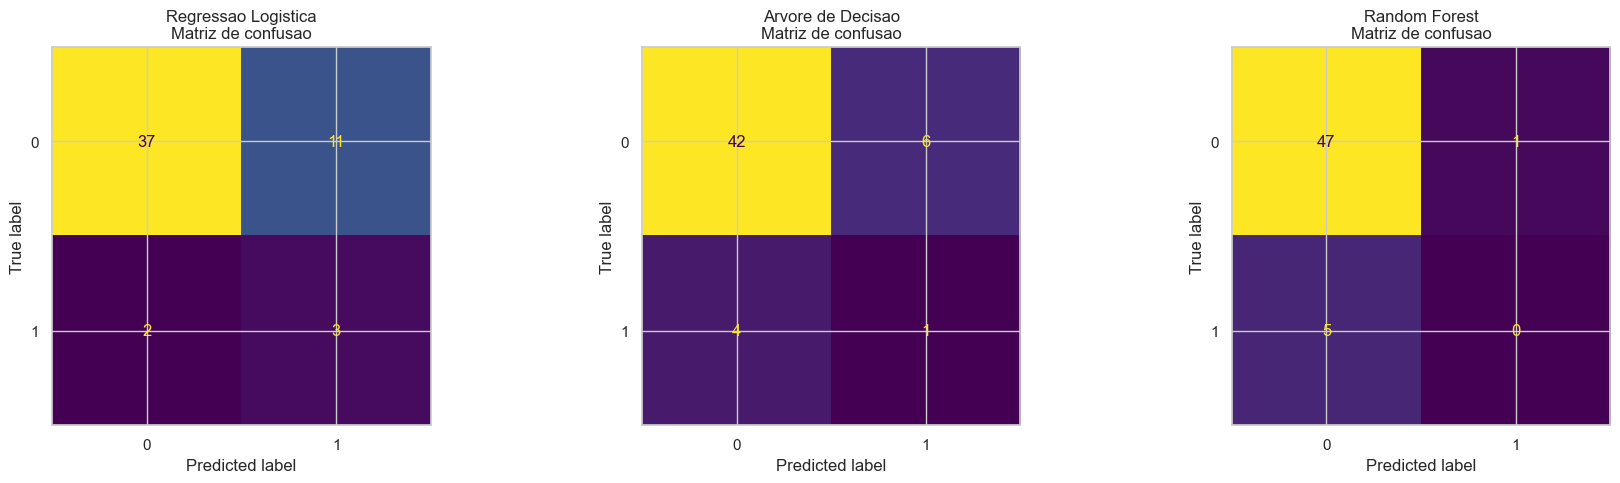

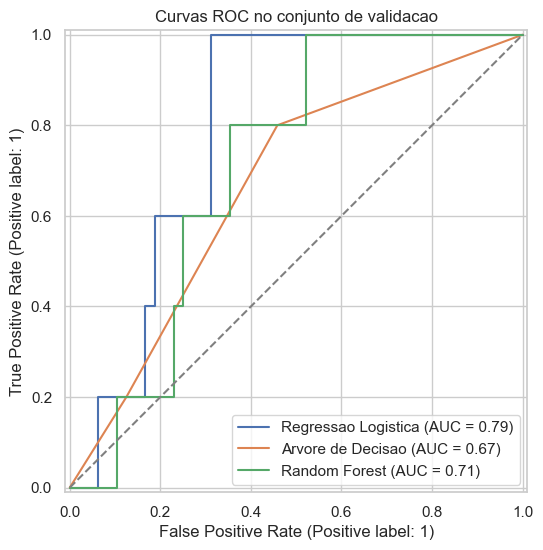

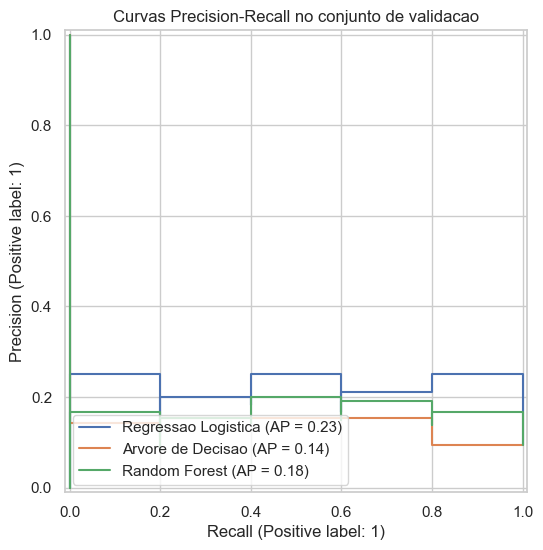

Melhor modelo na validacao: Regressao Logistica

Melhor threshold encontrado na validacao: 0.2


,threshold,f1,precision,recall
0,0.20,0.370370,0.227273,1.0
1,0.21,0.370370,0.227273,1.0
2,0.17,0.357143,0.217391,1.0
3,0.18,0.357143,0.217391,1.0
4,0.19,0.357143,0.217391,1.0
5,0.56,0.352941,0.250000,0.6
6,0.57,0.352941,0.250000,0.6
7,0.58,0.352941,0.250000,0.6
8,0.59,0.352941,0.250000,0.6
9,0.60,0.352941,0.250000,0.6



Metricas finais no conjunto de teste com threshold 0.50:
accuracy     0.8491
precision    0.3333
recall       0.6000
f1           0.4286
roc_auc      0.7375
dtype: float64

Metricas finais no conjunto de teste com threshold otimizado:
accuracy     0.6792
precision    0.2000
recall       0.8000
f1           0.3200
roc_auc      0.7375
dtype: float64

Threshold escolhido para o modelo final: 0.5
Metricas finais reportadas:
accuracy     0.8491
precision    0.3333
recall       0.6000
f1           0.4286
roc_auc      0.7375
dtype: float64


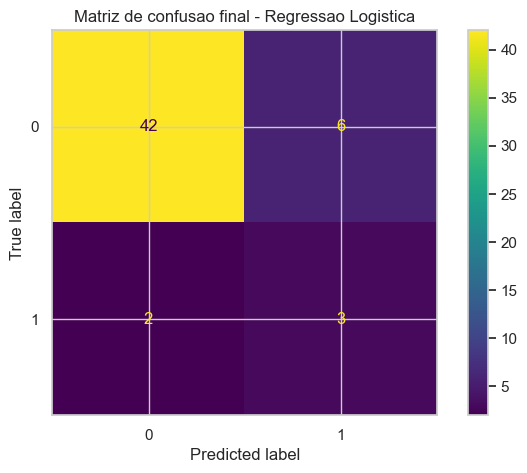


Pipeline guardado em: melhor_modelo_mudanca_CPAK.joblib

Exemplo de utilizacao da funcao final:
prever_novos_doentes(X_test.head())


In [10]:
# ============================================================
# 6) Comparar modelos, escolher o melhor e testar no fim
# ============================================================

# Juntar todos os resultados num unico DataFrame.
resultados_validacao = pd.DataFrame([
    resultado_lr_base,
    resultado_lr,
    resultado_dt_base,
    resultado_dt,
    resultado_rf_base,
    resultado_rf,
])

# Algumas linhas so terao tempo de treino quando essa informacao existir.
if 'tempo_segundos' not in resultados_validacao.columns:
    resultados_validacao['tempo_segundos'] = np.nan

# Ordenar pela metrica principal e depois por ROC-AUC.
resultados_validacao = resultados_validacao.sort_values(
    by=['f1', 'roc_auc'],
    ascending=False,
).reset_index(drop=True)

print('Tabela comparativa no conjunto de validacao:')
display(resultados_validacao)

# Guardar os melhores modelos otimizados num dicionario para facilitar os graficos.
modelos_otimizados = {
    'Regressao Logistica': melhor_lr,
    'Arvore de Decisao': melhor_dt,
    'Random Forest': melhor_rf,
}

previsoes_validacao = {
    'Regressao Logistica': (y_val_pred_lr, y_val_prob_lr),
    'Arvore de Decisao': (y_val_pred_dt, y_val_prob_dt),
    'Random Forest': (y_val_pred_rf, y_val_prob_rf),
}

# Desenhar as matrizes de confusao dos modelos otimizados.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nome_modelo in zip(axes, modelos_otimizados.keys()):
    y_pred_atual, _ = previsoes_validacao[nome_modelo]
    matriz = confusion_matrix(y_val, y_pred_atual)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{nome_modelo}\nMatriz de confusao')
plt.tight_layout()
plt.show()

# Desenhar curvas ROC dos modelos otimizados na mesma figura.
# Aqui usamos as probabilidades ja guardadas para garantir consistencia total.
fig, ax = plt.subplots(figsize=(8, 6))
for nome_modelo in modelos_otimizados.keys():
    _, y_prob_atual = previsoes_validacao[nome_modelo]
    RocCurveDisplay.from_predictions(y_val, y_prob_atual, name=nome_modelo, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('Curvas ROC no conjunto de validacao')
plt.show()

# Desenhar curvas Precision-Recall dos modelos otimizados na mesma figura.
fig, ax = plt.subplots(figsize=(8, 6))
for nome_modelo in modelos_otimizados.keys():
    _, y_prob_atual = previsoes_validacao[nome_modelo]
    PrecisionRecallDisplay.from_predictions(y_val, y_prob_atual, name=nome_modelo, ax=ax)
ax.set_title('Curvas Precision-Recall no conjunto de validacao')
plt.show()

# Escolher o melhor modelo com base no topo da tabela.
melhor_nome = resultados_validacao.loc[0, 'modelo']
print('Melhor modelo na validacao:', melhor_nome)

melhor_modelo_validacao = modelos_otimizados[melhor_nome]

# Afinar o threshold de classificacao no conjunto de validacao.
# Isto e util quando a classe positiva e rara, como acontece neste dataset.
prob_validacao_melhor = previsoes_validacao[melhor_nome][1]
thresholds = np.arange(0.10, 0.91, 0.01)
resultados_threshold = []

for threshold in thresholds:
    pred_threshold = (prob_validacao_melhor >= threshold).astype(int)
    resultados_threshold.append({
        'threshold': round(float(threshold), 2),
        'f1': f1_score(y_val, pred_threshold, zero_division=0),
        'precision': precision_score(y_val, pred_threshold, zero_division=0),
        'recall': recall_score(y_val, pred_threshold, zero_division=0),
    })

resultados_threshold = pd.DataFrame(resultados_threshold).sort_values(
    by=['f1', 'precision', 'recall'],
    ascending=False,
).reset_index(drop=True)

melhor_threshold = resultados_threshold.loc[0, 'threshold']
print('\nMelhor threshold encontrado na validacao:', melhor_threshold)
display(resultados_threshold.head(10))

# Reunir treino e validacao para treinar a versao final do melhor modelo.
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

# Criar uma copia limpa do melhor modelo antes de o voltar a ajustar.
melhor_modelo_final = clone(melhor_modelo_validacao)
melhor_modelo_final.fit(X_train_final, y_train_final)

# Comparar threshold padrao (0.50) com threshold otimizado.
y_test_prob = melhor_modelo_final.predict_proba(X_test)[:, 1]
y_test_pred_padrao = (y_test_prob >= 0.50).astype(int)
y_test_pred_otimizado = (y_test_prob >= melhor_threshold).astype(int)

metricas_teste_padrao = calcular_metricas(y_test, y_test_pred_padrao, y_test_prob)
metricas_teste_otimizado = calcular_metricas(y_test, y_test_pred_otimizado, y_test_prob)

print('\nMetricas finais no conjunto de teste com threshold 0.50:')
print(pd.Series(metricas_teste_padrao).round(4))
print('\nMetricas finais no conjunto de teste com threshold otimizado:')
print(pd.Series(metricas_teste_otimizado).round(4))

# Neste caso, o threshold ajustado aumentou o recall, mas piorou o F1.
# Como o objetivo principal e equilibrar precision e recall, vamos manter o threshold padrao.
threshold_final = 0.50
y_test_pred_final = y_test_pred_padrao
metricas_teste_finais = metricas_teste_padrao

print('\nThreshold escolhido para o modelo final:', threshold_final)
print('Metricas finais reportadas:')
print(pd.Series(metricas_teste_finais).round(4))

# Mostrar a matriz de confusao final com o threshold escolhido.
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_final)
plt.title(f'Matriz de confusao final - {melhor_nome}')
plt.show()

# Guardar o pipeline final para reutilizacao futura.
joblib.dump(melhor_modelo_final, 'melhor_modelo_mudanca_CPAK.joblib')
print('\nPipeline guardado em: melhor_modelo_mudanca_CPAK.joblib')

# Criar uma funcao simples para fazer previsoes em novos dados.
def prever_novos_doentes(novos_dados_df, modelo_final=melhor_modelo_final, threshold=threshold_final):
    probabilidades = modelo_final.predict_proba(novos_dados_df)[:, 1]
    classes_previstas = (probabilidades >= threshold).astype(int)
    return pd.DataFrame({
        'probabilidade_mudanca_CPAK': probabilidades,
        'classe_prevista': classes_previstas,
    }, index=novos_dados_df.index)

print('\nExemplo de utilizacao da funcao final:')
print('prever_novos_doentes(X_test.head())')